# Homework — Multi-Asset Market Structure EDA

Use this notebook to explore a synthetic cross-asset dataset in the language of **the Street**.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


trades = pd.read_csv("./data\\trades.csv.gz", parse_dates=["execution_timestamp", "trade_date"])
counterparties = pd.read_csv("./data\\counterparties.csv")
traders = pd.read_csv("./data\\traders.csv")
instruments = pd.read_csv("./data\\instruments.csv")
events = pd.read_csv("./data\\market_events.csv", parse_dates=["event_date"])

data = {
    "trades": trades,
    "counterparties": counterparties,
    "traders": traders,
    "instruments": instruments,
    "events": events
}


In [ ]:
# Summary statistics
for name, df in data.items():
    print(f"{name}\n")
    
    # Data types
    print(f"Data types:\n{df.dtypes}\n")
    
    # Broken rows
    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    for num_col in numeric_cols:
        df[num_col] = pd.to_numeric(df[num_col], errors="coerce")
    
    # Duplicates
    non_id_cols = [col for col in df.columns if "_id" not in col]
    print(f"Duplicate rows: {df.duplicated(subset=non_id_cols).sum()}\n")
    
    # String standarization
    string_cols = df.select_dtypes(include=["object", "string"]).columns
    for str_col in string_cols:
        df[str_col] = df[str_col].str.lower().str.replace("-", "_")

    # Null values
    nulls = df.isna().sum()
    print(f"Null values:\n{nulls[nulls > 0]}\n")

trades

Data types:
trade_id                       object
execution_timestamp    datetime64[ns]
trade_date             datetime64[ns]
trader_id                      object
desk                           object
counterparty_id                object
instrument_id                  object
asset_class                    object
product_type                   object
buy_sell                       object
venue                          object
market_structure               object
quantity                        int64
price                         float64
notional_usd                  float64
spread_bps                    float64
slippage_bps                  float64
execution_fee_usd             float64
risk_usd                      float64
pnl_1d_usd                    float64
pnl_5d_usd                    float64
settlement_days                 int64
is_block_trade                  int64
trade_status                   object
event_day_flag                  int64
dtype: object

Duplicate rows:

In [12]:
# Merged data
df_merged = trades
for name, df in data.items():
    if name == "trades":
        continue
    elif name == "counterparties":
        df_merged = df_merged.merge(counterparties, on="counterparty_id", how="left", suffixes=("", "_counterparty"))
    elif name == "traders":
        df_merged = df_merged.merge(traders, on="trader_id", how="left", suffixes=("", "_trader"))
    elif name == "instruments":
        df_merged = df_merged.merge(instruments, on="instrument_id", how="left", suffixes=("", "_instr"))
    elif name == "events":
        df_merged = df_merged.merge(events, left_on="trade_date", right_on="event_date", how="left", suffixes=("", "_event"))
    else:
        continue
suffixes = ["_counterparty", "_trader", "_instr", "_event"]

for col in df_merged.columns:
    for suffix in suffixes:
        if col.endswith(suffix):
            base_col = col.replace(suffix, "")
            if base_col in df_merged.columns:
                if df_merged[base_col].equals(df_merged[col]):
                    df_merged.drop(columns=[col], inplace=True)

print(f"Data types:\n{df_merged.dtypes}\n")

Data types:
trade_id                           object
execution_timestamp        datetime64[ns]
trade_date                 datetime64[ns]
trader_id                          object
desk                               object
counterparty_id                    object
instrument_id                      object
asset_class                        object
product_type                       object
buy_sell                           object
venue                              object
market_structure                   object
quantity                            int64
price                             float64
notional_usd                      float64
spread_bps                        float64
slippage_bps                      float64
execution_fee_usd                 float64
risk_usd                          float64
pnl_1d_usd                        float64
pnl_5d_usd                        float64
settlement_days                     int64
is_block_trade                      int64
trade_status          

In [13]:
# Derived fields
df_merged["execution_hour"] = df_merged["execution_timestamp"].dt.hour
df_merged["execution_month"] = df_merged["execution_timestamp"].dt.month
df_merged["is_event_window"] = np.where(df_merged["event_day_flag"] == 1, "Event Window", "Non-Event Window")
df_merged["abs_pnl_1d"] = df_merged["pnl_1d_usd"].abs()
df_merged["fee_bps_estimate"] = df_merged["execution_fee_usd"] / df_merged["notional_usd"] * 10000
df_merged["risk_to_notional"] = df_merged["risk_usd"] / df_merged["notional_usd"]
df_merged["pnl_to_risk"] = df_merged["pnl_1d_usd"] / df_merged["risk_usd"]

asset_class              commodity  equity  fixed income    fx
participant_type                                              
asset manager                    0   15299          8009  8526
broker dealer                    0    8180          6428  6787
bulge bracket bank            5422   10309          4889  5878
central bank                     0       0          5652  4063
commodity trading house       4625       0             0  5939
corporate treasury            8848       0         10584  7200
hedge fund                    9416   16454          8553  8032
insurance company                0       0          4274  4638
pension fund                     0   10227          4326     0
prop trading firm             7407   10357             0  4636
regional bank                    0       0          8461  5280
sovereign wealth fund            0    4200          4290  4011

product_type             cash equity  cds index  commodity future  \
participant_type                                

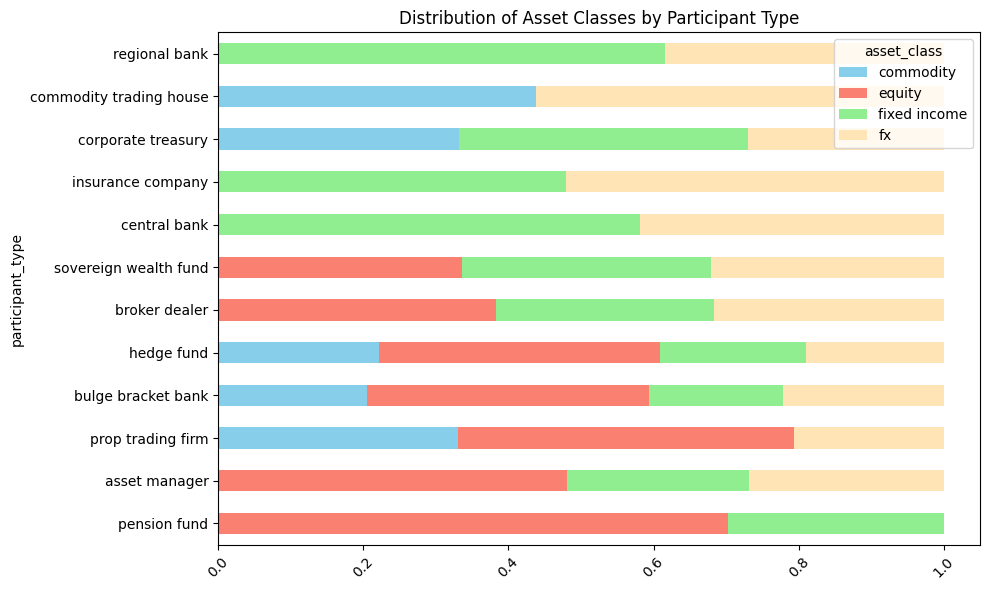

In [14]:
# 3.A.1
colors = ["skyblue", "salmon", "lightgreen", "moccasin"]

pa_type_by_as_cls = pd.crosstab(df_merged["participant_type"], df_merged["asset_class"])
pa_type_by_as_cls_norm = pa_type_by_as_cls.div(pa_type_by_as_cls.sum(axis=1), axis=0)
pa_type_by_as_cls_norm_sorted = pa_type_by_as_cls_norm.sort_values(by="equity", ascending=False)
pa_type_by_as_cls_norm_sorted.plot(kind="barh", stacked=True, figsize=(10, 6), color=colors)

pa_type_by_pr_type = pd.crosstab(df_merged["participant_type"], df_merged["product_type"])

plt.xticks(rotation=45)
plt.title("Distribution of Asset Classes by Participant Type")
plt.tight_layout()

print(pa_type_by_as_cls)
print("================================\n")
print(pa_type_by_pr_type)


asset_class         commodity  equity  fixed income    fx
participant_type                                         
hedge fund               9416   16454          8553  8032
corporate treasury       8848       0         10584  7200


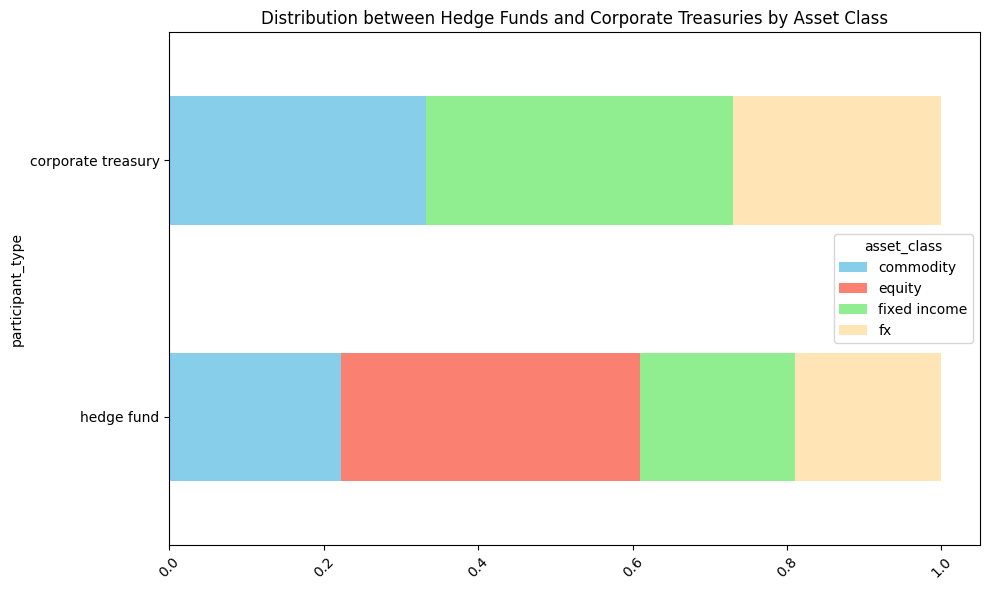

In [15]:
# 3.A.2
colors = ["skyblue", "salmon", "lightgreen", "moccasin"]

hf_and_ct = pd.crosstab(df_merged["participant_type"], df_merged["asset_class"]).loc[["hedge fund", "corporate treasury"]]
hf_and_ct_norm = hf_and_ct.div(hf_and_ct.sum(axis=1), axis=0)
hf_and_ct_norm_sorted = hf_and_ct_norm.sort_values(by="equity", ascending=False)
hf_and_ct_norm_sorted.plot(kind="barh", stacked=True, figsize=(10, 6), color=colors)

plt.xticks(rotation=45)
plt.title("Distribution between Hedge Funds and Corporate Treasuries by Asset Class")
plt.tight_layout()

print(hf_and_ct)


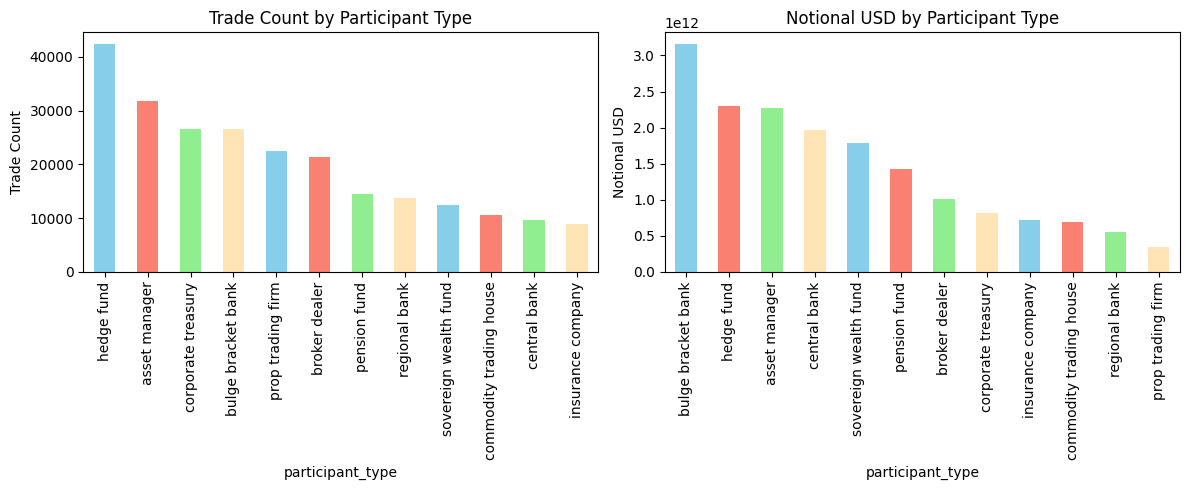

participant_type
asset manager              31834
broker dealer              21395
bulge bracket bank         26498
central bank                9715
commodity trading house    10564
corporate treasury         26632
hedge fund                 42455
insurance company           8912
pension fund               14553
prop trading firm          22400
regional bank              13741
sovereign wealth fund      12501
Name: trade_id, dtype: int64

participant_type
asset manager              2.265498e+12
broker dealer              1.015021e+12
bulge bracket bank         3.162607e+12
central bank               1.965576e+12
commodity trading house    6.934096e+11
corporate treasury         8.208363e+11
hedge fund                 2.299578e+12
insurance company          7.226580e+11
pension fund               1.424144e+12
prop trading firm          3.452053e+11
regional bank              5.517360e+11
sovereign wealth fund      1.786868e+12
Name: notional_usd, dtype: float64



In [17]:
# # 3.A.3
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["skyblue", "salmon", "lightgreen", "moccasin"]

as_cls_by_count = df_merged.groupby("participant_type")["trade_id"].count()
as_cls_by_notional = df_merged.groupby("participant_type")["notional_usd"].sum()
configs = [
    (as_cls_by_count, "Trade Count by Participant Type", "Trade Count"),
    (as_cls_by_notional, "Notional USD by Participant Type", "Notional USD")
]

for ax, cfg in zip(axes, configs):
    data, title, ylabel = cfg
    data.sort_values(ascending=False).plot(kind="bar", ax=ax, title=title, color=colors)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(ax.get_xticklabels())

plt.tight_layout()
plt.show()

print(as_cls_by_count)
print("================================\n")
print(as_cls_by_notional)
print("================================\n")


asset_class       commodity  equity  fixed income     fx
market_structure                                        
dealer_to_client      31835   61735         51239  52114
interdealer            3883   13291         14227  12876

asset_class  commodity  equity  fixed income     fx
venue                                              
dark pool            0   10513             0      0
dma                  0   14818             0      0
ecn                  0       0             0  15684
exchange         11033   49508           185    190
otc              15986     187         48854  49116
voice             8699       0         16427      0



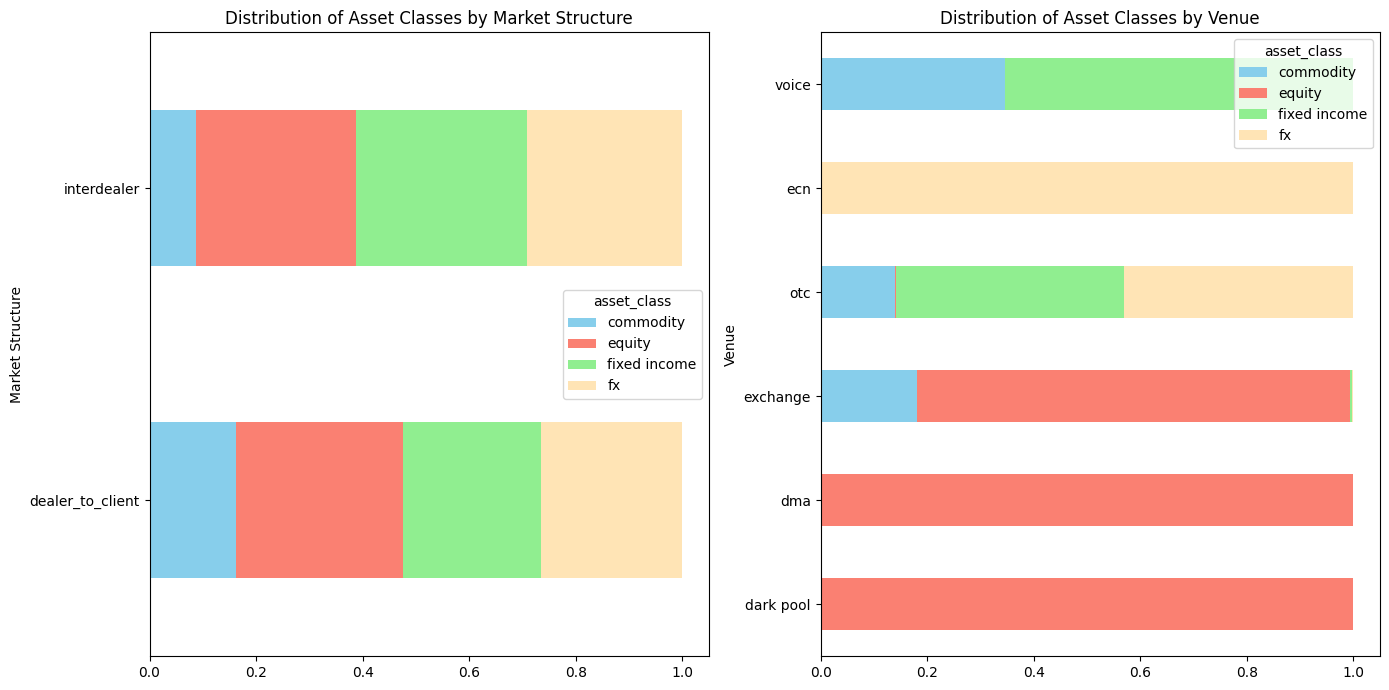

Average spread_bps by Venue:
venue
dark pool     5.302955
dma           3.915055
ecn           1.575808
exchange      4.116760
otc          11.153100
voice        15.617983
Name: spread_bps, dtype: float64


Average slippage_bps by Venue:
venue
dark pool    0.114635
dma          0.199347
ecn          0.226587
exchange     0.221333
otc          0.216940
voice        0.262929
Name: slippage_bps, dtype: float64


Average execution_fee_usd by Venue:
venue
dark pool     3619.647465
dma           3277.485988
ecn           2250.390058
exchange      4451.244892
otc           8950.355878
voice        10582.933096
Name: execution_fee_usd, dtype: float64




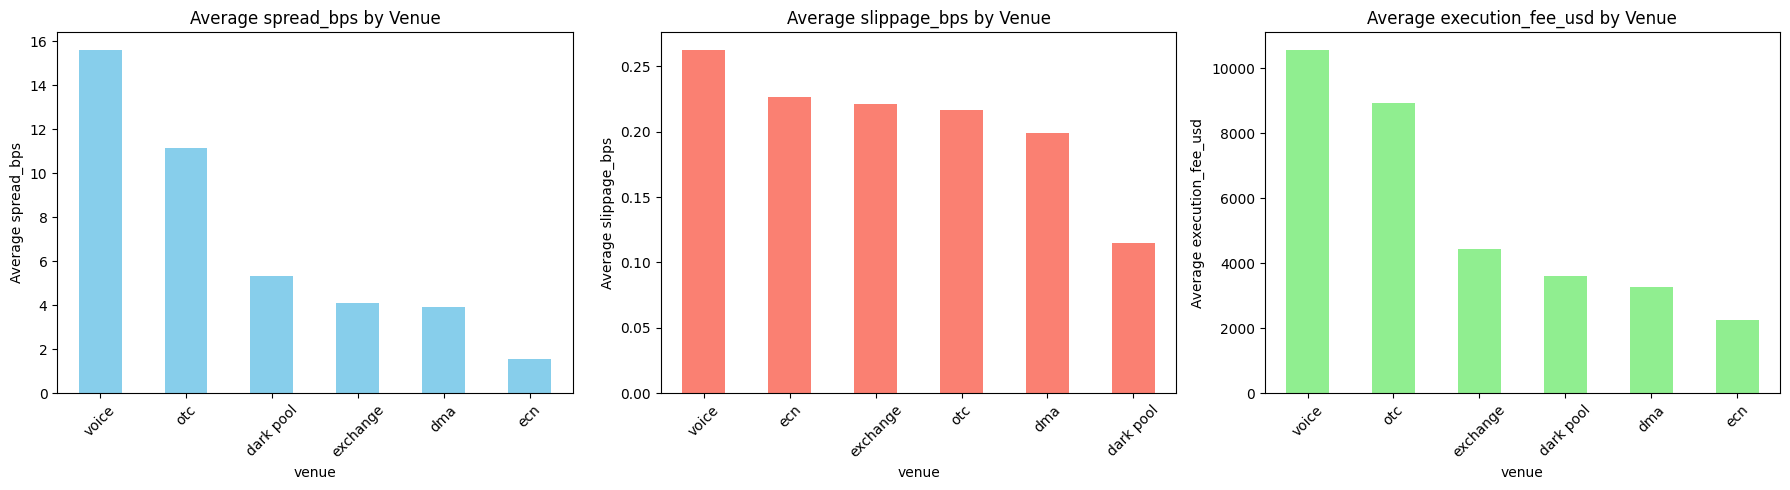

In [ ]:
fig_as_cls, axes_as_cls = plt.subplots(1, 2, figsize=(14, 7))
colors = ["skyblue", "salmon", "lightgreen", "moccasin"]

# 3.B.1
m_str_by_as_cls = pd.crosstab(df_merged["market_structure"], df_merged["asset_class"])
print(m_str_by_as_cls)
print("================================\n")

# 3.B.2
venue_by_as_cls = pd.crosstab(df_merged["venue"], df_merged["asset_class"])
print(venue_by_as_cls)
print("================================\n")

configs = [
    (m_str_by_as_cls, "Distribution of Asset Classes by Market Structure", "Market Structure"),
    (venue_by_as_cls, "Distribution of Asset Classes by Venue", "Venue")
]

for ax, cfg in zip(axes_as_cls, configs):
    data, title, ylabel = cfg
    data_norm = data.div(data.sum(axis=1), axis=0)
    data_norm.sort_values(by="equity", ascending=False).plot(kind="barh", stacked=True, ax=ax, title=title, color=colors)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()

# 3.B.3
stats = [
    ("spread_bps", "skyblue"),
    ("slippage_bps", "salmon"),
    ("execution_fee_usd", "lightgreen")
    ]

fig_stats, axes_stats = plt.subplots(1, 3, figsize=(18, 5))
for ax, stat in zip(axes_stats, stats):
    stat_name, color = stat
    venue_stats = df_merged.groupby("venue")[stat_name].mean()
    venue_stats.sort_values(ascending=False).plot(kind="bar", ax=ax, title=f"Average {stat_name} by Venue", color=color)
    ax.set_ylabel(f"Average {stat_name}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    print(f"Average {stat_name} by Venue:\n{venue_stats}\n")
    print("================================\n")

plt.tight_layout()
plt.show()


Execution quality by asset_class:

              spread_bps  slippage_bps  execution_fee_usd
asset_class                                              
commodity      11.388361      0.215695        5855.116880
equity          3.842886      0.206567        4228.976088
fixed income   15.643427      0.235898       10309.627174
fx              5.160147      0.214174        7374.162425

commodity
equity
fixed income
fx


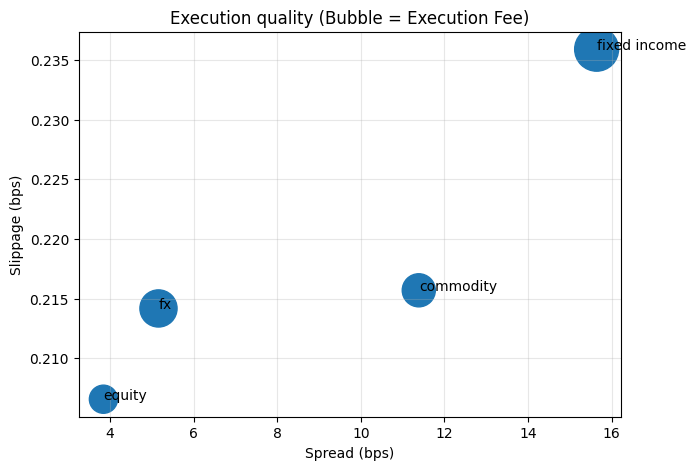

Execution quality by participant_type:

                         spread_bps  slippage_bps  execution_fee_usd
participant_type                                                    
asset manager              7.162970      0.235753        6327.243924
broker dealer              7.444270      0.201734        4478.635501
bulge bracket bank         7.116319      0.192446       11121.396921
central bank              10.971829      0.241766       24257.754841
commodity trading house    8.438511      0.192795        7011.922544
corporate treasury        12.030337      0.242914        3609.874287
hedge fund                 8.571433      0.207880        5075.318869
insurance company         10.175999      0.244582        9394.242407
pension fund               7.597396      0.249554        7857.255160
prop trading firm          5.790547      0.210405        1327.477867
regional bank             11.831161      0.205520        4778.974064
sovereign wealth fund      8.409135      0.209274       13918.4

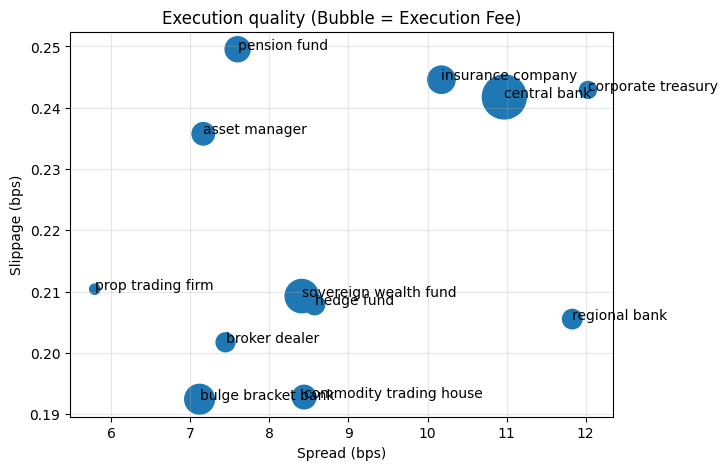

Execution quality by venue:

           spread_bps  slippage_bps  execution_fee_usd
venue                                                 
dark pool    5.302955      0.114635        3619.647465
dma          3.915055      0.199347        3277.485988
ecn          1.575808      0.226587        2250.390058
exchange     4.116760      0.221333        4451.244892
otc         11.153100      0.216940        8950.355878
voice       15.617983      0.262929       10582.933096

dark pool
dma
ecn
exchange
otc
voice


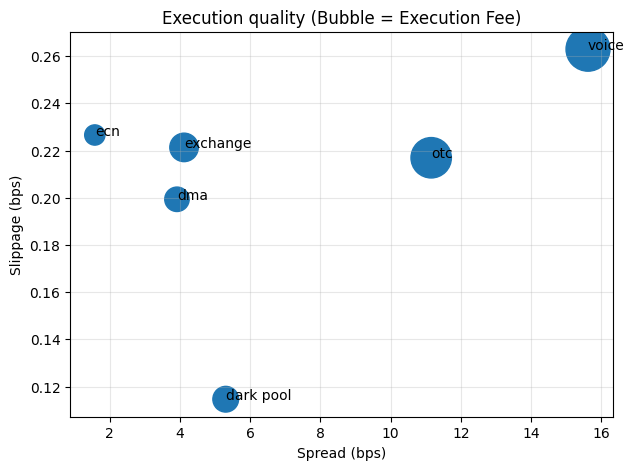

Execution quality by is_event_window:

                  spread_bps  slippage_bps  execution_fee_usd
is_event_window                                              
Event Window       10.685106      0.255686        7548.168388
Non-Event Window    7.920566      0.207516        6808.447247

Event Window
Non-Event Window


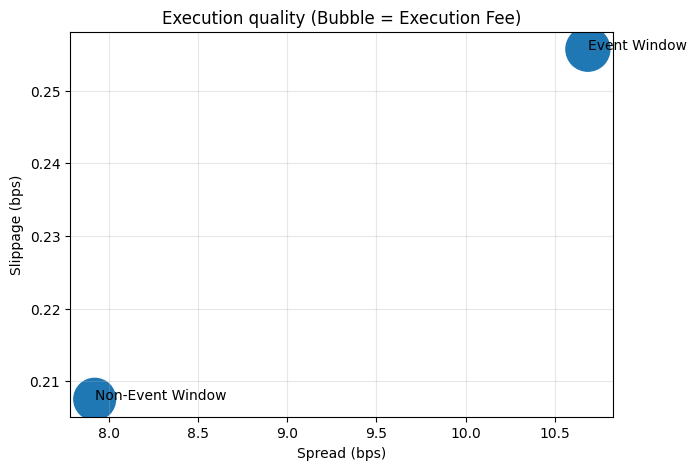

In [ ]:
# 3.C
exec_quality = ["asset_class", "participant_type", "venue", "is_event_window"]

for param in exec_quality:
    print(f"Execution quality by {param}:\n")
    print(df_merged.groupby(param)[["spread_bps", "slippage_bps", "execution_fee_usd"]].mean())
    print("================================\n")

    df_exec_quality = df_merged.groupby(param)[["spread_bps", "slippage_bps", "execution_fee_usd"]].mean()

    plt.figure(figsize=(7,5))

    plt.scatter(
        df_exec_quality["spread_bps"],
        df_exec_quality["slippage_bps"],
        s=(df_exec_quality["execution_fee_usd"] / df_exec_quality["execution_fee_usd"].max()) * 1000
    )

    for txt in df_exec_quality.index:
        plt.annotate(txt, (df_exec_quality["spread_bps"][txt], df_exec_quality["slippage_bps"][txt]))

    plt.xlabel("Spread (bps)")
    plt.ylabel("Slippage (bps)")
    plt.grid(alpha=0.3)
    plt.title("Execution quality (Bubble = Execution Fee)")
    plt.show()


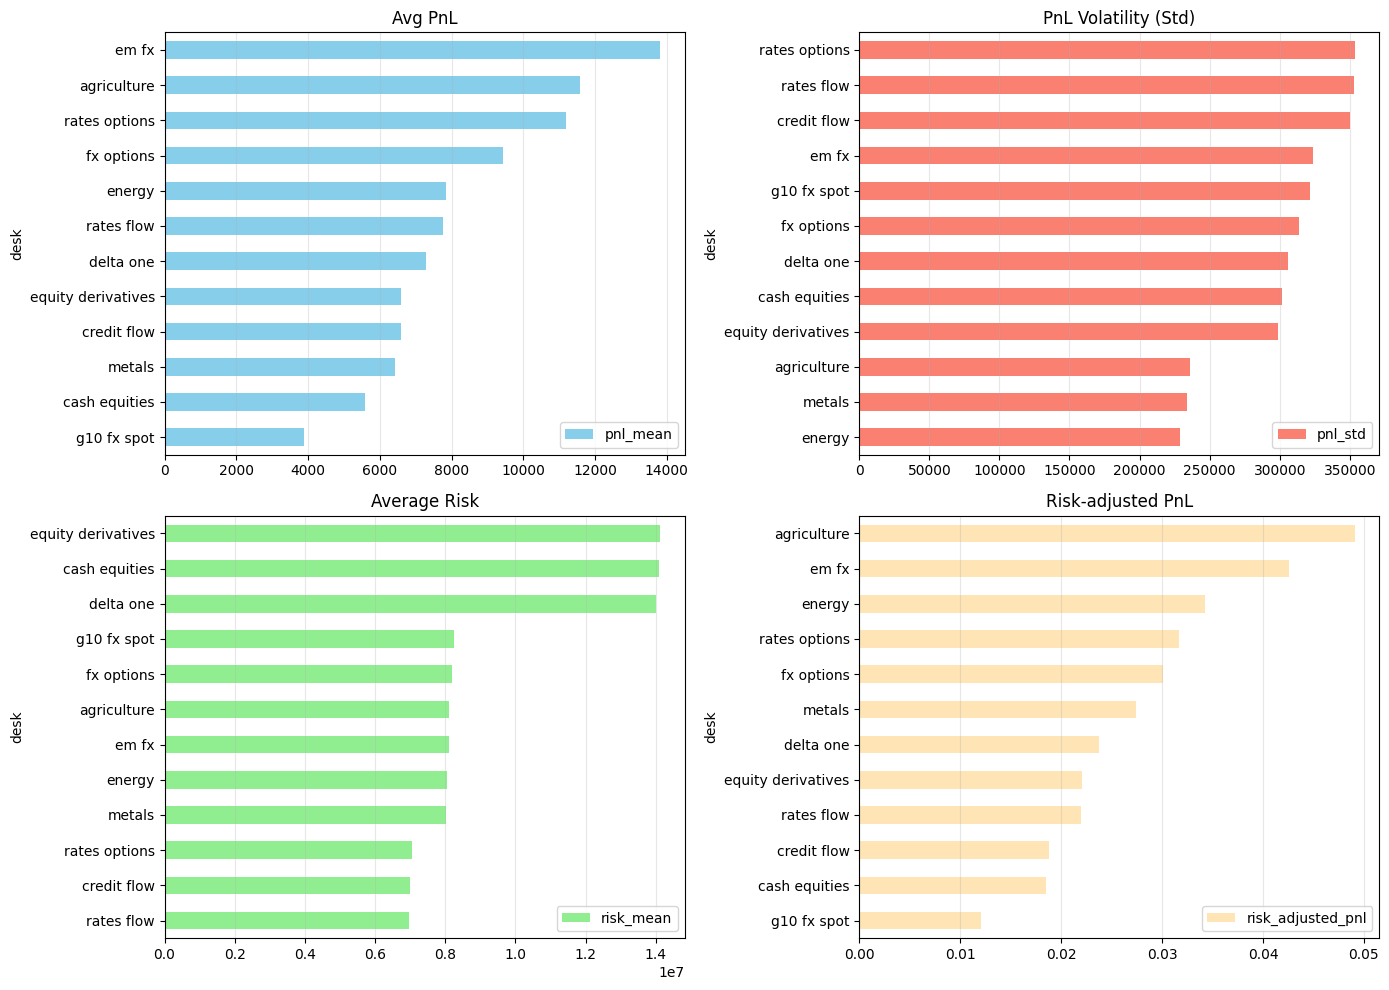

Highest avg PnL desk:

    desk      pnl_mean        pnl_std     risk_mean  risk_adjusted_pnl
4  em fx  13808.042828  324040.323865  8.116392e+06           0.042612

Highest PnL volatility desk:

             desk     pnl_mean        pnl_std     risk_mean  risk_adjusted_pnl
11  rates options  11188.95706  353469.132151  7.050463e+06           0.031655

Highest risk desk:

                 desk     pnl_mean        pnl_std     risk_mean  \
6  equity derivatives  6601.984089  298523.408807  1.411721e+07   

   risk_adjusted_pnl  
6           0.022115  

Highest risk-adjusted PnL desk:

          desk      pnl_mean        pnl_std     risk_mean  risk_adjusted_pnl
0  agriculture  11569.428151  235692.649108  8.119974e+06           0.049087

                         min           max  count
notional_bucket                                  
Small              836814.12  2.452469e+07  60300
Medium           24525418.42  4.680616e+07  60300
Large            46806189.67  8.781585e+07  60300
X-Lar

C:\Users\bstankie\AppData\Local\Temp\ipykernel_16992\3668906103.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_merged.groupby('notional_bucket')['notional_usd'].agg(['min', 'max', 'count']))
C:\Users\bstankie\AppData\Local\Temp\ipykernel_16992\3668906103.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_merged.groupby("notional_bucket")[["spread_bps", "slippage_bps", "execution_fee_usd"]].mean())


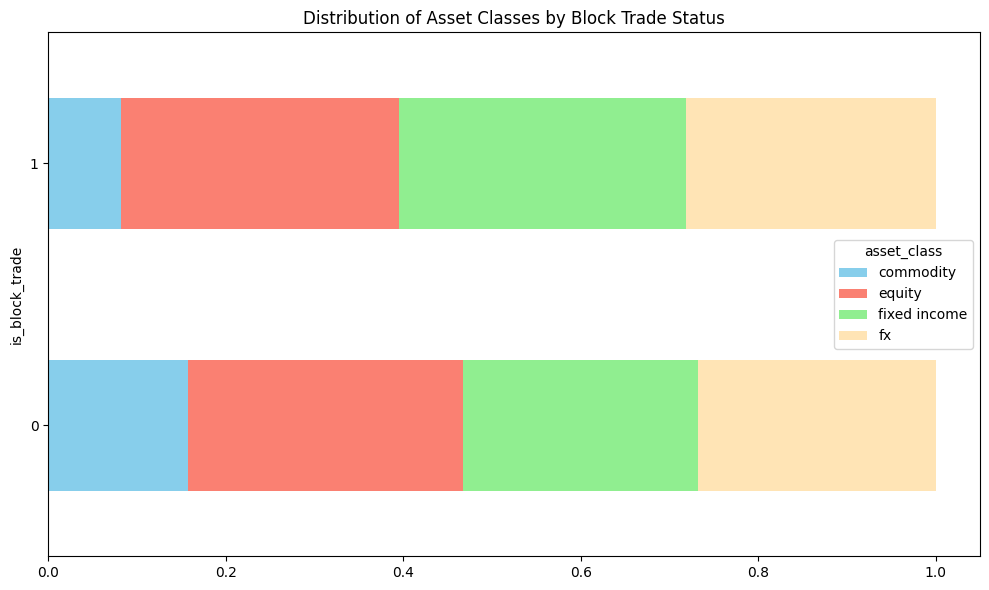

In [ ]:
# 3.D.1
df_desks = df_merged.groupby("desk").agg(
    pnl_mean=("pnl_1d_usd", "mean"),
    pnl_std=("pnl_1d_usd", "std"),
    risk_mean=("risk_usd", "mean")
).reset_index()

df_desks["risk_adjusted_pnl"] = df_desks["pnl_mean"] / df_desks["pnl_std"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

configs = [
    ("pnl_mean", "Avg PnL", "skyblue"),
    ("pnl_std", "PnL Volatility (Std)", "salmon"),
    ("risk_mean", "Average Risk", "lightgreen"),
    ("risk_adjusted_pnl", "Risk-adjusted PnL", "moccasin")
]

for ax, cfg in zip(axes.flatten(), configs):
    stat_name, title, color = cfg
    df_desks.sort_values(stat_name).plot(kind="barh", x="desk", y=stat_name, ax=ax, color=color)
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

configs_top = [
    ("pnl_mean", "Highest avg PnL desk"),
    ("pnl_std", "Highest PnL volatility desk"),
    ("risk_mean", "Highest risk desk"),
    ("risk_adjusted_pnl", "Highest risk-adjusted PnL desk")
]

for cfg in configs_top:
    stat_name, title = cfg
    print(f"{title}:\n")
    print(df_desks.sort_values(by=stat_name, ascending=False).head(1))
    print("================================\n")

# 3.D.2
df_merged["notional_bucket"] = pd.qcut(df_merged["notional_usd"], q=4, labels=["Small", "Medium", "Large", "X-Large"])
print(df_merged.groupby("notional_bucket")["notional_usd"].agg(["min", "max", "count"]))
print("================================\n")
print(df_merged.groupby("notional_bucket")[["spread_bps", "slippage_bps", "execution_fee_usd"]].mean())
print("================================\n")

# 3.D.3
print(df_merged.groupby("is_block_trade")[["spread_bps", "slippage_bps", "execution_fee_usd", "notional_usd", "pnl_1d_usd"]].mean())
print("================================\n")
print(pd.crosstab(df_merged["is_block_trade"], df_merged["asset_class"]))

colors = ["skyblue", "salmon", "lightgreen", "moccasin"]
blk_trade_by_as_cls = pd.crosstab(df_merged["is_block_trade"], df_merged["asset_class"])
blk_trade_by_as_cls_norm = blk_trade_by_as_cls.div(blk_trade_by_as_cls.sum(axis=1), axis=0)
blk_trade_by_as_cls_norm.plot(kind="barh", stacked=True, figsize=(10, 6), color=colors)
plt.title("Distribution of Asset Classes by Block Trade Status")
plt.tight_layout()
plt.show()


execution_hour
7      4382
8     17457
9     32584
10    32426
11    26334
12    22925
13    24039
14    28179
15    31370
16    17489
17     4015
Name: trade_id, dtype: int64

execution_hour
7     3.186015e+11
8     1.253892e+12
9     2.305149e+12
10    2.303525e+12
11    1.847223e+12
12    1.639873e+12
13    1.685847e+12
14    1.982156e+12
15    2.199709e+12
16    1.233955e+12
17    2.832063e+11
Name: notional_usd, dtype: float64

execution_month
1     21575
2     19896
3     19018
4     21380
5     21477
6     20593
7     22335
8     19055
9     19723
10    22383
11    19879
12    13886
Name: trade_id, dtype: int64

execution_month
1     1.518559e+12
2     1.419732e+12
3     1.339684e+12
4     1.516625e+12
5     1.532831e+12
6     1.461878e+12
7     1.582051e+12
8     1.321307e+12
9     1.375429e+12
10    1.593953e+12
11    1.410766e+12
12    9.803231e+11
Name: notional_usd, dtype: float64

is_event_window
Event Window        21.620647
Non-Event Window    78.379353
Name: trade_id, d

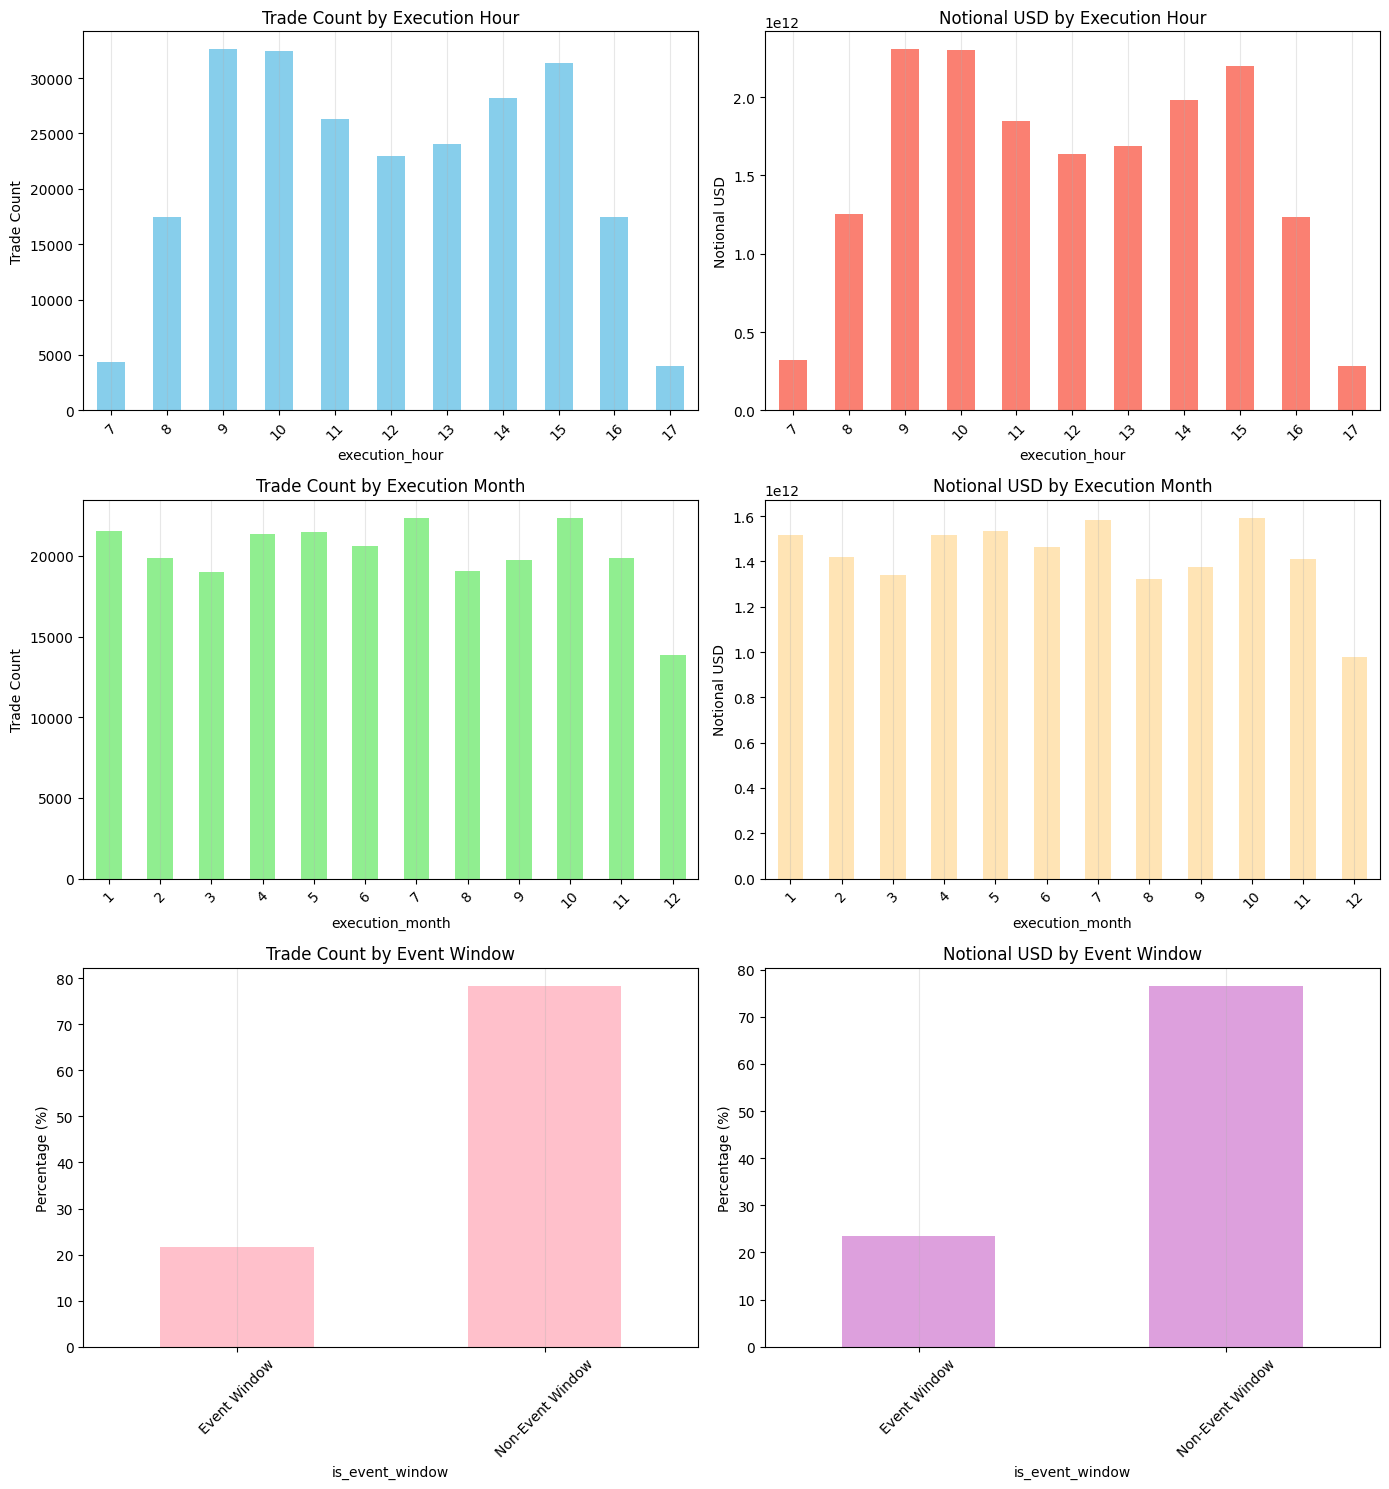

asset_class       commodity  equity  fixed income     fx
is_event_window                                         
Event Window           7730   16257         14126  14036
Non-Event Window      27988   58769         51340  50954


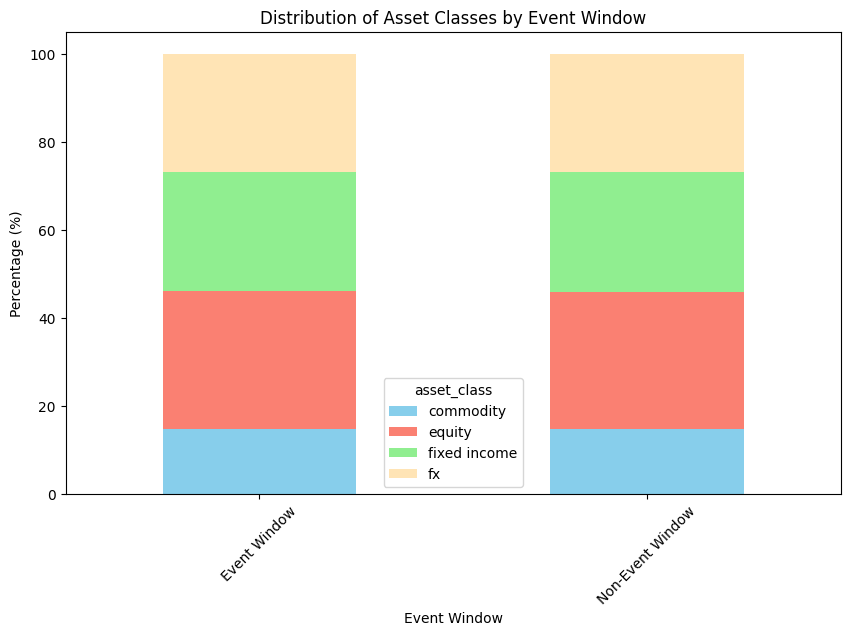

In [ ]:
# 3.E.1
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

exec_hour_by_id = df_merged.groupby("execution_hour")["trade_id"].count()
exec_hour_by_notional = df_merged.groupby("execution_hour")["notional_usd"].sum()

exec_month_by_id = df_merged.groupby("execution_month")["trade_id"].count()
exec_month_by_notional = df_merged.groupby("execution_month")["notional_usd"].sum()

even_window_by_id = df_merged.groupby("is_event_window")["trade_id"].count()
even_window_by_id_pct = even_window_by_id.div(even_window_by_id.sum()) * 100
even_window_by_notional = df_merged.groupby("is_event_window")["notional_usd"].sum()
even_window_by_notional_pct = even_window_by_notional.div(even_window_by_notional.sum()) * 100

config_hour = [
    (exec_hour_by_id, "Trade Count by Execution Hour", "Trade Count", "skyblue"),
    (exec_hour_by_notional, "Notional USD by Execution Hour", "Notional USD", "salmon"),
    (exec_month_by_id, "Trade Count by Execution Month", "Trade Count", "lightgreen"),
    (exec_month_by_notional, "Notional USD by Execution Month", "Notional USD", "moccasin"),
    (even_window_by_id_pct, "Trade Count by Event Window", "Percentage (%)", "pink"),
    (even_window_by_notional_pct, "Notional USD by Event Window", "Percentage (%)", "plum")
]

for ax, cfg in zip(axes.flatten(), config_hour):
    data, title, ylabel, color = cfg
    data.plot(kind="bar", ax=ax, color=color)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="x", alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    print(data)
    print("================================\n")

plt.tight_layout()
plt.show()

# 3.E.2
colors = ["skyblue", "salmon", "lightgreen", "moccasin"]
even_window_by_asset_class = pd.crosstab(df_merged["is_event_window"], df_merged["asset_class"])
even_window_by_asc_pct = even_window_by_asset_class.div(even_window_by_asset_class.sum(axis=1), axis=0) * 100
even_window_by_asc_pct.plot(kind="bar", stacked=True, figsize=(10, 6), color=colors)
plt.title("Distribution of Asset Classes by Event Window")
plt.xlabel("Event Window")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
print(pd.crosstab(df_merged["is_event_window"], df_merged["asset_class"]))


In [134]:
# 3.F.1
negative_price = df_merged[df_merged["price"] < 0]
zero_quantity = df_merged[df_merged["quantity"] == 0]
negative_fee = df_merged[df_merged["execution_fee_usd"] < 0]
extreme_notional = df_merged[df_merged["notional_usd"] > df_merged["notional_usd"].quantile(0.99)]
non_id_cols = [col for col in df_merged.columns if "_id" not in col]
duplicated = df_merged[df_merged.duplicated(subset=non_id_cols)]

cols = ["trade_id", "price", "asset_class", "product_type", "quantity", "execution_fee_usd", "notional_usd"]
configs = [
    (negative_price, "Negative prices"),
    (zero_quantity, "Zero quantity"),
    (negative_fee, "Negative fee"),
    (extreme_notional, "Extreme notional"),
    (duplicated, "Duplicate rows")
]

for cfg in configs:
    df, title = cfg
    print(f"{title} count: {len(df)}")
    print(df[cols].head())
    print("================================\n")

# 3.F.2
df_merged["is_suspect_trade"] = np.where(
    (df_merged["price"] < 0) |
    (df_merged["quantity"] == 0) |
    (df_merged["execution_fee_usd"] < 0) |
    (df_merged.duplicated(subset=non_id_cols)),
    "Suspect Trade",
    "Normal Trade"
)

print(df_merged.groupby("is_suspect_trade")[["trade_id"]].count())


Negative prices count: 80
       trade_id       price   asset_class     product_type  quantity  \
4789   t0074558 -141.548079        equity              etf    338112   
5577   t0185319  -53.478913            fx       fx forward    100000   
7764   t0227432 -144.305928            fx       fx forward    100000   
10867  t0223521  -93.784813  fixed income  government bond    159000   
12503  t0196004  -21.096137        equity    equity option       650   

       execution_fee_usd  notional_usd  
4789             2871.55  4.785911e+07  
5577            16265.53  1.270562e+08  
7764             7034.99  5.426830e+07  
10867           26638.07  1.588885e+08  
12503            1258.12  1.370458e+07  

Zero quantity count: 101
       trade_id       price asset_class   product_type  quantity  \
4005   t0092577   22.461108      equity  equity option         0   
7236   t0070974  270.873281      equity    cash equity         0   
7599   t0197935  252.011161      equity    cash equity         0 

## Suggested steps
1. Profile data quality
2. Standardize categories
3. Merge dimension tables
4. Derive new features
5. Analyze liquidity, participation, market structure and P&L
6. Write an executive summary
